C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\3426013444.py:16: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])


Homes per hometype:
 hometype
flat                 144
house_or_bungalow    110
Name: home_id, dtype: int64

Rows per hometype:
 hometype
flat                 869253
house_or_bungalow    660097
Name: count, dtype: int64


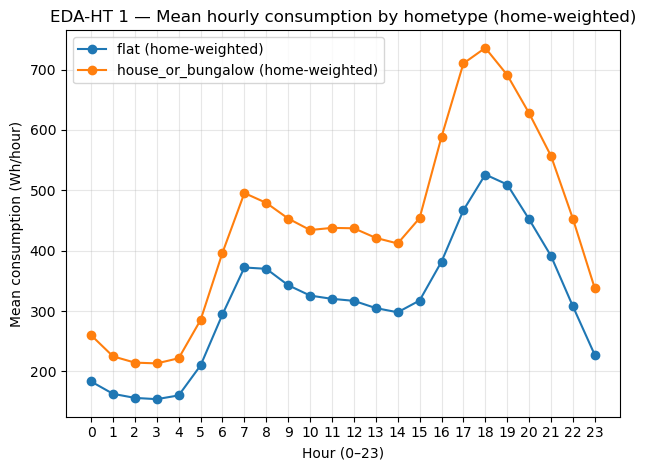

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_hometype\EDA_HT_01_mean_consumption_by_hour_weighted.png


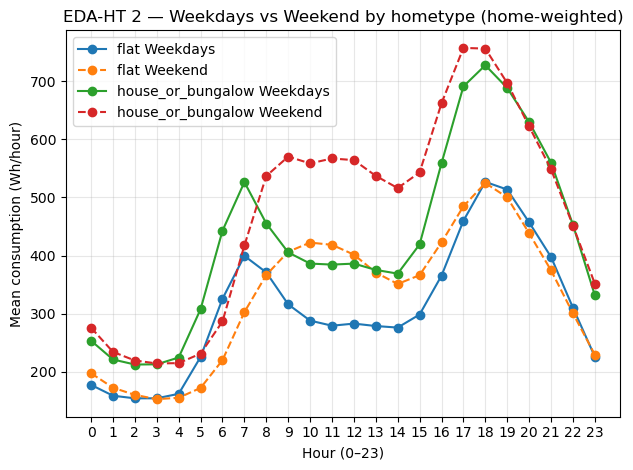

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_hometype\EDA_HT_02_weekday_weekend_by_hour_weighted.png

EDA-HT 3 (flat) rows before dropna: 869253, after: 869253, dropped: 0

EDA-HT 3 (house_or_bungalow) rows before dropna: 660097, after: 660097, dropped: 0


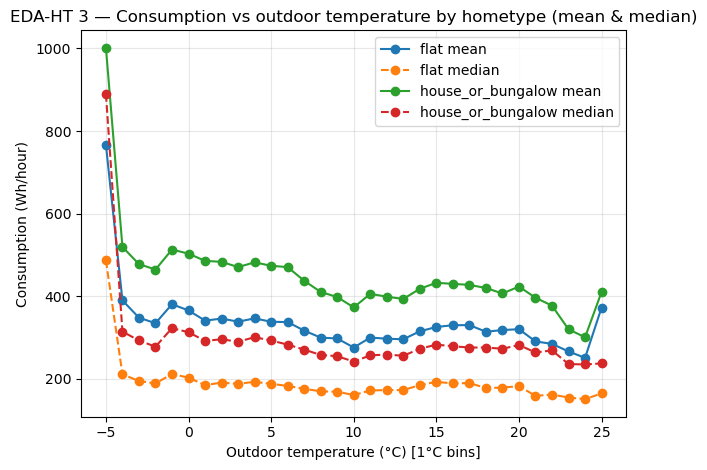

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_hometype\EDA_HT_03_consumption_vs_outdoor_temp_mean_median.png


C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\3426013444.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


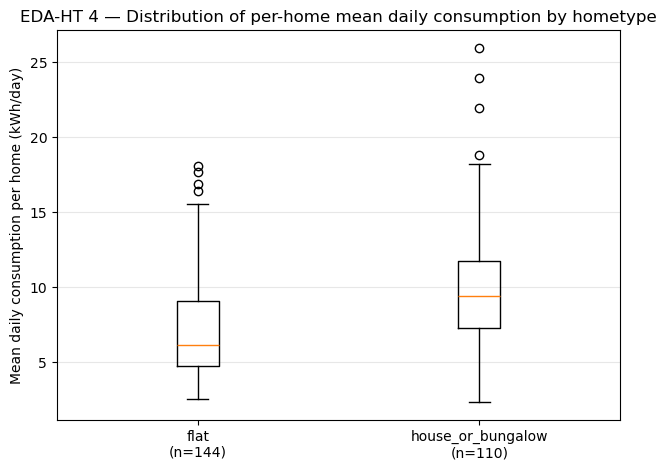

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_hometype\EDA_HT_04_mean_daily_kWh_boxplot_showfliers.png

Plots saved to: C:\IDEAL_Programming\processed\plots\eda_new\by_hometype


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"
PLOTS_DIR = BASE_DIR / "processed" / "plots" / "eda_new" / "by_hometype"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Load
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

# Core columns check
need = ["home_id", "timestamp", "consumption_Wh", "hometype", "is_weekend", "external_temperature"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

# Keep only the 2 main types
df = df[df["hometype"].isin(["flat", "house_or_bungalow"])].copy()

# Sanity: homes per hometype + rows
homes_per_type = df.groupby("hometype")["home_id"].nunique().sort_values(ascending=False)
rows_per_type = df["hometype"].value_counts()
print("Homes per hometype:\n", homes_per_type)
print("\nRows per hometype:\n", rows_per_type)

def save_show(name: str):
    out = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# ==========================================================
# Plot 1 (Improved): Mean hourly consumption by hometype (home-weighted)
# ==========================================================
plt.figure()

for ht in ["flat", "house_or_bungalow"]:
    g = df[df["hometype"] == ht]

    # home-weighted mean by hour:
    # step1: per-home mean at each hour
    # step2: average across homes (equal weight)
    hw = (
        g.groupby(["home_id", "hour"])["consumption_Wh"].mean()
         .reset_index()
         .groupby("hour")["consumption_Wh"].mean()
         .sort_index()
    )

    plt.plot(hw.index, hw.values, marker="o", label=f"{ht} (home-weighted)")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-HT 1 — Mean hourly consumption by hometype (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_HT_01_mean_consumption_by_hour_weighted.png")

# ==========================================================
# Plot 2 (Improved): Weekdays vs Weekend by hometype (home-weighted)
# ==========================================================
plt.figure()

for ht in ["flat", "house_or_bungalow"]:
    g = df[df["hometype"] == ht]

    wd = (
        g[g["is_weekend"] == 0]
        .groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
    )

    we = (
        g[g["is_weekend"] == 1]
        .groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
    )

    plt.plot(wd.index, wd.values, marker="o", label=f"{ht} Weekdays")
    plt.plot(we.index, we.values, marker="o", linestyle="--", label=f"{ht} Weekend")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-HT 2 — Weekdays vs Weekend by hometype (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_HT_02_weekday_weekend_by_hour_weighted.png")

# ==========================================================
# Plot 3 (Improved): Consumption vs outdoor temperature by hometype
# - 1°C bins
# - mean + median
# - counts per bin (optional annotation for sparse bins)
# ==========================================================
plt.figure()

for ht in ["flat", "house_or_bungalow"]:
    g = df[df["hometype"] == ht][["external_temperature", "consumption_Wh"]].copy()

    before = len(g)
    g = g.dropna()
    after = len(g)
    print(f"\nEDA-HT 3 ({ht}) rows before dropna: {before}, after: {after}, dropped: {before - after}")

    g["temp_bin"] = g["external_temperature"].round(0).astype(int)

    stats = (
        g.groupby("temp_bin")["consumption_Wh"]
         .agg(mean="mean", median="median", count="count")
         .reset_index()
         .sort_values("temp_bin")
    )

    # plot mean (solid) and median (dashed) for each hometype
    plt.plot(stats["temp_bin"], stats["mean"], marker="o", label=f"{ht} mean")
    plt.plot(stats["temp_bin"], stats["median"], marker="o", linestyle="--", label=f"{ht} median")

    # annotate very sparse bins (optional)
    sparse = stats[stats["count"] < 50]
    for _, r in sparse.iterrows():
        plt.text(r["temp_bin"], r["mean"], f"n={int(r['count'])}", fontsize=8)

plt.xlabel("Outdoor temperature (°C) [1°C bins]")
plt.ylabel("Consumption (Wh/hour)")
plt.title("EDA-HT 3 — Consumption vs outdoor temperature by hometype (mean & median)")
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_HT_03_consumption_vs_outdoor_temp_mean_median.png")

# ==========================================================
# Plot 4 (Improved): Mean daily consumption per home by hometype (kWh/day)
# - showfliers=True (EDA)
# - annotate n homes
# ==========================================================
daily = (
    df.groupby(["home_id", "hometype", "date"])["consumption_Wh"]
      .sum()
      .reset_index()
)

mean_daily = (
    daily.groupby(["home_id", "hometype"])["consumption_Wh"]
         .mean()
         .reset_index()
)

mean_daily["mean_daily_kWh"] = mean_daily["consumption_Wh"] / 1000.0

data_flat = mean_daily.loc[mean_daily["hometype"] == "flat", "mean_daily_kWh"].values
data_house = mean_daily.loc[mean_daily["hometype"] == "house_or_bungalow", "mean_daily_kWh"].values

n_flat = (mean_daily["hometype"] == "flat").sum()
n_house = (mean_daily["hometype"] == "house_or_bungalow").sum()

plt.figure()
plt.boxplot(
    [data_flat, data_house],
    labels=[f"flat\n(n={n_flat})", f"house_or_bungalow\n(n={n_house})"],
    showfliers=True
)
plt.ylabel("Mean daily consumption per home (kWh/day)")
plt.title("EDA-HT 4 — Distribution of per-home mean daily consumption by hometype")
plt.grid(True, axis="y", alpha=0.3)
save_show("EDA_HT_04_mean_daily_kWh_boxplot_showfliers.png")

print("\nPlots saved to:", PLOTS_DIR)
